In [38]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import time
import json
from tqdm import tqdm

# Инициализация MediaPipe
mp_face_mesh = mp.solutions.face_mesh
mp_pose = mp.solutions.pose

# Индексы для Face Mesh
LEFT_EYE = [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398]
RIGHT_EYE = [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246]
LEFT_IRIS = [474, 475, 476, 477]
RIGHT_IRIS = [469, 470, 471, 472]

### --- МЕТОД 1: Текущий (Baseline из Charisma Master) ---

In [39]:
def analyze_gaze_baseline(face_landmarks):
    # Копия логики из ml_engine.py
    face = face_landmarks.landmark
    nose_x = face[1].x
    left_ear = face[234].x
    right_ear = face[454].x

    face_width = abs(right_ear - left_ear)
    face_center = (left_ear + right_ear) / 2

    if face_width > 0:
        deviation = abs(nose_x - face_center) / face_width
        return 1.0 if deviation < 0.25 else 0.0
    return 0.0

### --- МЕТОД 2: Face Mesh Head Pose (Углы поворота головы) ---

In [40]:
def get_head_pose_v2(face_landmarks, img_w, img_h):
    # 1 - кончик носа, 152 - подбородок, 33 - левый угол левого глаза,
    # 263 - правый угол правого глаза, 61 - левый угол рта, 291 - правый угол рта
    face_2d = []
    indices = [1, 152, 33, 263, 61, 291]

    # Примерные 3D координаты модели лица
    model_3d = np.array([
        [0.0, 0.0, 0.0],          # Нос
        [0.0, -330.0, -65.0],    # Подбородок
        [-225.0, 170.0, -135.0], # Левый глаз
        [225.0, 170.0, -135.0],  # Правый глаз
        [-150.0, -150.0, -125.0],# Левый рот
        [150.0, -150.0, -125.0]  # Правый рот
    ], dtype=np.float64)

    for idx in indices:
        lm = face_landmarks.landmark[idx]
        face_2d.append([lm.x * img_w, lm.y * img_h])

    face_2d = np.array(face_2d, dtype=np.float64)
    focal_length = img_w
    cam_matrix = np.array([[focal_length, 0, img_w / 2],
                           [0, focal_length, img_h / 2],
                           [0, 0, 1]])

    success, rot_vec, trans_vec = cv2.solvePnP(model_3d, face_2d, cam_matrix, np.zeros((4, 1)))
    rmat, _ = cv2.Rodrigues(rot_vec)

    # Прямой расчет углов
    pitch = np.arcsin(-rmat[2, 0])
    yaw = np.arctan2(rmat[2, 1], rmat[2, 2])

    return np.degrees(pitch), np.degrees(yaw)

### --- МЕТОД 3: Тяжелый (Face Mesh + Iris Tracking + Pose Orientation) ---

In [41]:
def get_gaze_ratio(face_landmarks, eye_indices, iris_indices):
    lm = face_landmarks.landmark
    # Берем X-координаты краев глаза
    # eye_indices[0] - внутренний угол, eye_indices[8] - внешний угол
    x_left = lm[eye_indices[0]].x
    x_right = lm[eye_indices[8]].x
    
    # Средний X зрачка
    x_iris = np.mean([lm[i].x for i in iris_indices])
    
    # Вычисляем, где зрачок относительно углов глаза (0.0 - 1.0)
    width = abs(x_right - x_left)
    if width == 0: return 0.5
    
    # Находим относительную позицию
    ratio = (x_iris - min(x_left, x_right)) / width
    return ratio

def analyze_gaze_advanced(face_landmarks, pose_landmarks, pitch, raw_yaw, img_w, img_h):
    # 1. Нормализация Yaw
    yaw = raw_yaw - 180 if raw_yaw > 0 else raw_yaw + 180
    
    # 2. Текущее положение зрачков
    ratio_l = get_gaze_ratio(face_landmarks, LEFT_EYE, LEFT_IRIS)
    ratio_r = get_gaze_ratio(face_landmarks, RIGHT_EYE, RIGHT_IRIS)
    avg_gaze = (ratio_l + ratio_r) / 2

    # 3. Базовая отбраковка (если затылок или слишком сильный наклон)
    if not (-20 < pitch < 65) or abs(yaw) > 40:
        return False

    # 4. ДИНАМИЧЕСКИЙ РАСЧЕТ ИДЕАЛЬНОГО ВЗГЛЯДА В КАМЕРУ
    # Если yaw=0 (лицо прямо) -> глаза прямые (0.5)
    # Если yaw=-10 (лицо повернуто) -> глаза должны быть на 0.63 (0.5 - (-10 * 0.013))
    expected_gaze = 0.5 - (yaw * 0.013)
    
    # 5. Проверяем, насколько реальный взгляд совпадает с тем, который бьет ровно в объектив.
    # Жесткий допуск: погрешность всего ±0.08 (8% от ширины глаза).
    if abs(avg_gaze - expected_gaze) < 0.08:
        return True
        
    return False




### face crop

In [42]:
mp_face_detection = mp.solutions.face_detection

def extract_face_crop(frame, min_face_height_ratio=0.15, padding=0.25, target_height=480):
    """
    Если лицо маленькое (FAR) — вырезает и увеличивает его.
    Возвращает (кадр_для_анализа, is_far).
    Кадр_для_анализа — либо оригинал, либо кроп с увеличением.
    """
    h, w = frame.shape[:2]
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    with mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.4) as detector:
        res = detector.process(rgb)

    if not res.detections:
        return frame, False  # лицо не найдено — вернуть как есть

    bbox = res.detections[0].location_data.relative_bounding_box
    face_h_ratio = bbox.height

    # Лицо достаточно крупное — обработка как обычно
    if face_h_ratio >= min_face_height_ratio:
        return frame, False

    # --- FAR-режим: кроп + upscale ---
    pad_x = bbox.width  * padding
    pad_y = bbox.height * padding

    x1 = max(0.0, bbox.xmin - pad_x)
    y1 = max(0.0, bbox.ymin - pad_y)
    x2 = min(1.0, bbox.xmin + bbox.width  + pad_x)
    y2 = min(1.0, bbox.ymin + bbox.height + pad_y)

    # Переводим в пиксели
    x1p, y1p = int(x1 * w), int(y1 * h)
    x2p, y2p = int(x2 * w), int(y2 * h)

    crop = frame[y1p:y2p, x1p:x2p]
    if crop.size == 0:
        return frame, False

    # Масштабируем: высота = target_height
    scale = target_height / crop.shape[0]
    crop_resized = cv2.resize(crop, None, fx=scale, fy=scale, interpolation=cv2.INTER_LINEAR)

    return crop_resized, True


### вспомоательные функции кропа

In [43]:
def _detect_and_crop(frame, detector, min_face_h=0.15, padding=0.25, target_h=480):
    """Детектирует лицо и возвращает (кадр, is_far, bbox_или_None)."""
    h, w = frame.shape[:2]
    res = detector.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    if not res.detections:
        return frame, False, None

    bbox = res.detections[0].location_data.relative_bounding_box
    is_far = bbox.height < min_face_h

    if not is_far:
        return frame, False, None

    crop, bbox_px = _crop_face(frame, bbox, w, h, padding, target_h)
    return crop, True, bbox_px

def _crop_face(frame, bbox, w, h, padding, target_h):
    """Собственно вырезает и масштабирует."""
    pad_x = bbox.width  * padding
    pad_y = bbox.height * padding
    x1 = max(0, int((bbox.xmin - pad_x) * w))
    y1 = max(0, int((bbox.ymin - pad_y) * h))
    x2 = min(w, int((bbox.xmin + bbox.width  + pad_x) * w))
    y2 = min(h, int((bbox.ymin + bbox.height + pad_y) * h))
    bbox_px = (x1, y1, x2, y2)
    crop = frame[y1:y2, x1:x2]
    if crop.size == 0:
        return frame, None
    scale = target_h / crop.shape[0]
    return cv2.resize(crop, None, fx=scale, fy=scale,
                      interpolation=cv2.INTER_LINEAR), bbox_px

def _apply_cached_crop(frame, bbox_px, is_far, target_h=480):
    """Применяет сохранённый bbox без повторной детекции."""
    if not is_far or bbox_px is None:
        return frame
    x1, y1, x2, y2 = bbox_px
    crop = frame[y1:y2, x1:x2]
    if crop.size == 0:
        return frame
    scale = target_h / crop.shape[0]
    return cv2.resize(crop, None, fx=scale, fy=scale,
                      interpolation=cv2.INTER_LINEAR)


### main loop



In [44]:
def process_video_full_suite(video_path):
    cap = cv2.VideoCapture(video_path)
    results = {
        "baseline_hits": 0, "mesh_hits": 0, "advanced_hits": 0,
        "frames_with_face": 0, "total_processed_frames": 0,
        "far_frames": 0,
        "time_mediapipe": 0.0, "time_baseline": 0.0,
        "time_mesh": 0.0, "time_advanced": 0.0,
        "time_crop":      0.0,
        "time_mediapipe": 0.0,
        "time_baseline":  0.0,
        "time_mesh":      0.0,
        "time_advanced":  0.0
    }

    REDETECT_EVERY = 30
    PROCESS_WIDTH  = 480

    with mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.4) as detector, \
         mp_face_mesh.FaceMesh(refine_landmarks=True) as face_mesh, \
         mp_pose.Pose() as pose:

        is_far = False
        last_crop_bbox = None
        frames_since_redetect = 0

        while cap.isOpened():                   
            ret, frame = cap.read()
            if not ret: break

            results["total_processed_frames"] += 1
            if results["total_processed_frames"] % 5 != 0: continue

            # --- Кроп / детекция расстояния ---
            if frames_since_redetect >= REDETECT_EVERY or last_crop_bbox is None:
                t_start = time.perf_counter()
                frame_to_analyze, is_far, last_crop_bbox = _detect_and_crop(frame, detector)
                results["time_crop"] += time.perf_counter() - t_start
                frames_since_redetect = 0
            else:
                frame_to_analyze = _apply_cached_crop(frame, last_crop_bbox, is_far)
                frames_since_redetect += 1

            if is_far:
                results["far_frames"] += 1

            # --- Уменьшение NEAR-кадров ---
            h, w, _ = frame_to_analyze.shape
            if not is_far and w > PROCESS_WIDTH:
                scale_f = PROCESS_WIDTH / w
                frame_to_analyze = cv2.resize(
                    frame_to_analyze, None, fx=scale_f, fy=scale_f,
                    interpolation=cv2.INTER_LINEAR
                )
                h, w = frame_to_analyze.shape[:2]

            # --- Face Mesh ---
            t_start = time.perf_counter()
            face_results = face_mesh.process(cv2.cvtColor(frame_to_analyze, cv2.COLOR_BGR2RGB))
            results["time_mediapipe"] += time.perf_counter() - t_start

            if face_results.multi_face_landmarks:
                results["frames_with_face"] += 1
                face_lms = face_results.multi_face_landmarks[0]

                t_start = time.perf_counter()
                results["baseline_hits"] += analyze_gaze_baseline(face_lms)
                results["time_baseline"] += time.perf_counter() - t_start

                t_start = time.perf_counter()
                pitch, raw_yaw = get_head_pose_v2(face_lms, w, h)
                yaw_c = raw_yaw - 180 if raw_yaw > 0 else raw_yaw + 180
                if abs(yaw_c) < 15 and (-15 < pitch < 40):
                    results["mesh_hits"] += 1
                results["time_mesh"] += time.perf_counter() - t_start

                if results["frames_with_face"] % 20 == 0:
                    print(f"Debug [{video_path[-15:]}][{'FAR' if is_far else 'NEAR'}]: "
                          f"Pitch {pitch:.1f}, Yaw {yaw_c:.1f}")

                t_start = time.perf_counter()
                if analyze_gaze_advanced(face_lms, None, pitch, raw_yaw, w, h):
                    results["advanced_hits"] += 1
                results["time_advanced"] += time.perf_counter() - t_start

    cap.release()
    f = max(1, results["frames_with_face"])
    for k in ["baseline", "mesh", "advanced"]:
        results[f"score_{k}"] = results[f"{k}_hits"] / f

    processed = max(1, results["total_processed_frames"] // 5)
    results["far_ratio"] = round(results["far_frames"] / processed, 2)
    return results


In [ ]:
dataset = [
    {"path": "../media/custom_contact.mp4", "label": "ideal"},
    {"path": "../media/custom_contact(FAR).mp4", "label": "ideal_FAR"},
    {"path": "../media/custom_faceright_contact.mp4", "label": "ideal_face-right"},
    {"path": "../media/custom_faceright_contact(FAR).mp4", "label": "ideal_face-right_FAR"},
    {"path": "../media/custom_rotate_cantact.mp4", "label": "ideal_rotate"},
    {"path": "../media/custom_rotate_cantact(FAR).mp4", "label": "ideal_rotate_FAR"},
    {"path": "../media/custom_rotate_nocantact.mp4", "label": "ideal_rotate_FAR"},
    {"path": "../media/custom_rotate_nocantact(FAR).mp4", "label": "ideal_rotate_FAR"},
    {"path": "../media/custom_facedown_nocontact.mp4", "label": "bad_face-down"},
    {"path": "../media/custom_facedown_nocontact(FAR).mp4", "label": "bad_face-down_FAR"},
    {"path": "../media/custom_faceright_nocontact.mp4", "label": "bad_face-right"},
    {"path": "../media/custom_faceright_nocontact(FAR).mp4", "label": "bad_face-right_FAR"},
    {"path": "../media/expert_bad_light.mp4", "label": "expert_bad-light"},
    {"path": "../media/expert_glasses.mp4", "label": "expert_glasses"},
    {"path": "../media/no_eye_contact.mp4", "label": "bad"},
]

### запуск


In [46]:
all_stats = []
for video in dataset:
    try:
        print(f"Processing {video['path']}...")
        res = process_video_full_suite(video['path'])
        res.update({'video': video['path'], 'label': video['label']})
        all_stats.append(res)
    except Exception as e: print(f"Error: {e}")

display(pd.DataFrame(all_stats))

Processing ../media/custom_contact.mp4...


c:\Users\Vladimir\Documents\repos\py\UrFU\metrics-config-only-\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Debug [tom_contact.mp4][NEAR]: Pitch 11.6, Yaw 4.2
Debug [tom_contact.mp4][NEAR]: Pitch 10.4, Yaw 4.0
Debug [tom_contact.mp4][NEAR]: Pitch 12.1, Yaw 4.0
Debug [tom_contact.mp4][NEAR]: Pitch 15.0, Yaw 6.9
Debug [tom_contact.mp4][NEAR]: Pitch 11.2, Yaw 6.0
Debug [tom_contact.mp4][NEAR]: Pitch 11.4, Yaw 5.5
Debug [tom_contact.mp4][NEAR]: Pitch 10.9, Yaw 5.4
Debug [tom_contact.mp4][NEAR]: Pitch 12.4, Yaw 5.0
Debug [tom_contact.mp4][NEAR]: Pitch 10.8, Yaw 4.7
Debug [tom_contact.mp4][NEAR]: Pitch 10.2, Yaw 4.5
Debug [tom_contact.mp4][NEAR]: Pitch 9.0, Yaw 5.1
Debug [tom_contact.mp4][NEAR]: Pitch 8.6, Yaw 5.5
Debug [tom_contact.mp4][NEAR]: Pitch 13.0, Yaw 2.6
Debug [tom_contact.mp4][NEAR]: Pitch 11.1, Yaw 4.0
Debug [tom_contact.mp4][NEAR]: Pitch 12.7, Yaw 4.3
Debug [tom_contact.mp4][NEAR]: Pitch 12.1, Yaw 4.3
Debug [tom_contact.mp4][NEAR]: Pitch 9.2, Yaw 5.8
Debug [tom_contact.mp4][NEAR]: Pitch 10.3, Yaw 5.7
Debug [tom_contact.mp4][NEAR]: Pitch 10.9, Yaw 5.2
Debug [tom_contact.mp4][NEAR]: Pit

,baseline_hits,mesh_hits,advanced_hits,frames_with_face,total_processed_frames,far_frames,time_mediapipe,time_baseline,time_mesh,time_advanced,time_crop,score_baseline,score_mesh,score_advanced,far_ratio,video,label
0,1250.0,1250,1235,1250,6250,0,5.869031,0.017917,1.662810,0.118267,10.294065,1.000000,1.000000,0.988000,0.00,../media/custom_contact.mp4,ideal
1,1250.0,1250,1228,1250,6250,1250,4.443226,0.014537,0.981782,0.084269,0.254682,1.000000,1.000000,0.982400,1.00,../media/custom_contact(FAR).mp4,ideal_FAR
2,0.0,0,697,1200,6002,0,4.768843,0.016631,0.716115,0.093110,7.512337,0.000000,0.000000,0.580833,0.00,../media/custom_faceright_contact.mp4,ideal_face-right
3,0.0,0,725,1200,6004,1200,4.710053,0.014724,0.783374,0.086718,0.255032,0.000000,0.000000,0.604167,1.00,../media/custom_faceright_contact(FAR).mp4,ideal_face-right_FAR
4,704.0,522,271,1200,6004,0,6.398183,0.019921,1.385988,0.121648,10.113333,0.586667,0.435000,0.225833,0.00,../media/custom_rotate_cantact.mp4,ideal_rotate
5,632.0,551,286,1072,6005,1067,6.040005,0.015901,1.196952,0.099657,1.404607,0.589552,0.513993,0.266791,0.89,../media/custom_rotate_cantact(FAR).mp4,ideal_rotate_FAR
6,1190.0,0,0,1190,5950,0,5.683885,0.017930,1.059444,0.111399,9.160726,1.000000,0.000000,0.000000,0.00,../media/custom_facedown_nocontact.mp4,bad_face-down
7,1036.0,0,0,1036,5950,1036,4.018553,0.011772,0.733593,0.068694,1.097049,1.000000,0.000000,0.000000,0.87,../media/custom_facedown_nocontact(FAR).mp4,bad_face-down_FAR
8,0.0,82,34,1188,5974,0,5.918448,0.017125,1.400666,0.110783,10.187233,0.000000,0.069024,0.028620,0.00,../media/custom_faceright_nocontact.mp4,bad_face-right
9,0.0,12,27,1153,5975,1193,4.912251,0.013651,1.260309,0.086082,0.281549,0.000000,0.010408,0.023417,1.00,../media/custom_faceright_nocontact(FAR).mp4,bad_face-right_FAR


# расчет GAP

In [47]:
import numpy as np

GOOD_LABELS = {'ideal', 'ideal_face-right', 'ideal_rotate','ideal_FAR', 'ideal_face-right_FAR','ideal_rotate_FAR'}
BAD_LABELS  = {'bad', 'bad_face-down', 'bad_face-right', 'bad_FAR', 'bad_face-down_FAR', 'bad_face-right_FAR'}

df = pd.DataFrame(all_stats)

def compute_gap(df, score_col):
    """
    GAP = (mean_good - mean_bad) / pooled_std
    Стандартизированное расстояние между классами (аналог Cohen's d).
    Чем выше — тем лучше метрика различает хорошие и плохие видео.
    """
    good = df[df['label'].isin(GOOD_LABELS)][score_col]
    bad  = df[df['label'].isin(BAD_LABELS)][score_col]

    mean_good = good.mean()
    mean_bad  = bad.mean()

    # Объединённое стандартное отклонение (pooled std)
    n_g, n_b = len(good), len(bad)
    pooled_std = np.sqrt(
        ((n_g - 1) * good.std(ddof=1)**2 + (n_b - 1) * bad.std(ddof=1)**2)
        / (n_g + n_b - 2)
    )

    gap = (mean_good - mean_bad) / pooled_std if pooled_std > 0 else float('nan')
    return mean_good, mean_bad, pooled_std, gap

# Считаем для каждого метода
gap_summary = []
for method in ['baseline', 'mesh', 'advanced']:
    mean_g, mean_b, std, gap = compute_gap(df, f'score_{method}')
    gap_summary.append({
        'method':    method,
        'mean_good': round(mean_g, 3),
        'mean_bad':  round(mean_b, 3),
        'pooled_std': round(std, 3),
        'gap (Cohen\'s d)': round(gap, 3),
    })

gap_df = pd.DataFrame(gap_summary).set_index('method')
display(gap_df)


,mean_good,mean_bad,pooled_std,gap (Cohen's d)
method,,,,
baseline,0.529,0.446,0.479,0.174
mesh,0.491,0.042,0.336,1.336
advanced,0.608,0.018,0.247,2.388


### время обработки

In [48]:
df = pd.DataFrame(all_stats)

# Имя видео без пути
df['video_name'] = df['video'].apply(lambda p: p.split('/')[-1].replace('.mp4', ''))

# Полное время каждого метода:
# каждый метод несёт на себе стоимость кропа + FaceMesh + своя математика
df['total_baseline'] = df['time_crop'] + df['time_mediapipe'] + df['time_baseline']
df['total_mesh']     = df['time_crop'] + df['time_mediapipe'] + df['time_mesh']
df['total_advanced'] = df['time_crop'] + df['time_mediapipe'] + df['time_advanced']

# Округляем до 2 знаков (секунды)
time_cols = ['time_crop', 'time_mediapipe', 'time_baseline',
             'time_mesh', 'time_advanced',
             'total_baseline', 'total_mesh', 'total_advanced']
df[time_cols] = df[time_cols].round(2)

# --- Таблица 1: разбивка по компонентам ---
print("=== Разбивка времени по компонентам (сек) ===")
display(df[['video_name', 'label',
            'time_crop', 'time_mediapipe',
            'time_baseline', 'time_mesh', 'time_advanced']].set_index('video_name'))

# --- Таблица 2: итоговое время на видео по методам ---
print("\n=== Итоговое время обработки каждого видео по методам (сек) ===")
time_df = df[['video_name', 'label',
              'total_baseline', 'total_mesh', 'total_advanced']].set_index('video_name')
time_df.columns = ['label', 'Baseline (сек)', 'Head Pose (сек)', 'Advanced (сек)']
display(time_df)

# --- Итоговая строка: среднее по методам ---
print("\n=== Среднее время на одно видео ===")
means = {
    'Метод':         ['Baseline', 'Head Pose', 'Advanced'],
    'Среднее (сек)': [
        df['total_baseline'].mean().round(2),
        df['total_mesh'].mean().round(2),
        df['total_advanced'].mean().round(2),
    ],
    'Макс (сек)': [
        df['total_baseline'].max().round(2),
        df['total_mesh'].max().round(2),
        df['total_advanced'].max().round(2),
    ],
}
display(pd.DataFrame(means).set_index('Метод'))


=== Разбивка времени по компонентам (сек) ===


,label,time_crop,time_mediapipe,time_baseline,time_mesh,time_advanced
video_name,,,,,,
custom_contact,ideal,10.29,5.87,0.02,1.66,0.12
custom_contact(FAR),ideal_FAR,0.25,4.44,0.01,0.98,0.08
custom_faceright_contact,ideal_face-right,7.51,4.77,0.02,0.72,0.09
custom_faceright_contact(FAR),ideal_face-right_FAR,0.26,4.71,0.01,0.78,0.09
custom_rotate_cantact,ideal_rotate,10.11,6.40,0.02,1.39,0.12
custom_rotate_cantact(FAR),ideal_rotate_FAR,1.40,6.04,0.02,1.20,0.10
custom_facedown_nocontact,bad_face-down,9.16,5.68,0.02,1.06,0.11
custom_facedown_nocontact(FAR),bad_face-down_FAR,1.10,4.02,0.01,0.73,0.07
custom_faceright_nocontact,bad_face-right,10.19,5.92,0.02,1.40,0.11



=== Итоговое время обработки каждого видео по методам (сек) ===


,label,Baseline (сек),Head Pose (сек),Advanced (сек)
video_name,,,,
custom_contact,ideal,16.18,17.83,16.28
custom_contact(FAR),ideal_FAR,4.71,5.68,4.78
custom_faceright_contact,ideal_face-right,12.30,13.00,12.37
custom_faceright_contact(FAR),ideal_face-right_FAR,4.98,5.75,5.05
custom_rotate_cantact,ideal_rotate,16.53,17.90,16.63
custom_rotate_cantact(FAR),ideal_rotate_FAR,7.46,8.64,7.54
custom_facedown_nocontact,bad_face-down,14.86,15.90,14.96
custom_facedown_nocontact(FAR),bad_face-down_FAR,5.13,5.85,5.18
custom_faceright_nocontact,bad_face-right,16.12,17.51,16.22



=== Среднее время на одно видео ===


,Среднее (сек),Макс (сек)
Метод,,
Baseline,10.18,16.53
Head Pose,11.27,17.90
Advanced,10.25,16.63


### no face crop

In [49]:
def process_video_no_crop(video_path):
    """Обработка без FaceDetection-кропа — для сравнения скорости."""
    cap = cv2.VideoCapture(video_path)
    results = {
        "baseline_hits": 0, "mesh_hits": 0, "advanced_hits": 0,
        "frames_with_face": 0, "total_processed_frames": 0,
        "time_mediapipe": 0.0, "time_baseline": 0.0,
        "time_mesh": 0.0, "time_advanced": 0.0,
        "time_crop": 0.0,  # всегда 0, для совместимости с формулой
    }

    PROCESS_WIDTH = 480  # уменьшаем кадр до 480px — единственная оптимизация

    with mp_face_mesh.FaceMesh(refine_landmarks=True) as face_mesh:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break

            results["total_processed_frames"] += 1
            if results["total_processed_frames"] % 5 != 0: continue

            # Ресайз без детекции лица
            h, w, _ = frame.shape
            if w > PROCESS_WIDTH:
                scale_f = PROCESS_WIDTH / w
                frame = cv2.resize(frame, None, fx=scale_f, fy=scale_f,
                                   interpolation=cv2.INTER_LINEAR)
                h, w = frame.shape[:2]

            t_start = time.perf_counter()
            face_results = face_mesh.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            results["time_mediapipe"] += time.perf_counter() - t_start

            if face_results.multi_face_landmarks:
                results["frames_with_face"] += 1
                face_lms = face_results.multi_face_landmarks[0]

                t_start = time.perf_counter()
                results["baseline_hits"] += analyze_gaze_baseline(face_lms)
                results["time_baseline"] += time.perf_counter() - t_start

                t_start = time.perf_counter()
                pitch, raw_yaw = get_head_pose_v2(face_lms, w, h)
                yaw_c = raw_yaw - 180 if raw_yaw > 0 else raw_yaw + 180
                if abs(yaw_c) < 15 and (-15 < pitch < 40):
                    results["mesh_hits"] += 1
                results["time_mesh"] += time.perf_counter() - t_start

                t_start = time.perf_counter()
                if analyze_gaze_advanced(face_lms, None, pitch, raw_yaw, w, h):
                    results["advanced_hits"] += 1
                results["time_advanced"] += time.perf_counter() - t_start

    cap.release()
    f = max(1, results["frames_with_face"])
    for k in ["baseline", "mesh", "advanced"]:
        results[f"score_{k}"] = results[f"{k}_hits"] / f
    results["far_ratio"] = 0.0
    return results


In [50]:

all_stats_no_crop = []
for video in dataset:
    try:
        print(f"Processing {video['path']}...")
        res = process_video_no_crop(video['path'])
        res.update({'video': video['path'], 'label': video['label']})
        all_stats_no_crop.append(res)
    except Exception as e:
        print(f"Error: {e}")

# --- Сборка таблиц ---
df_nc = pd.DataFrame(all_stats_no_crop)
df_nc['video_name'] = df_nc['video'].apply(lambda p: p.split('/')[-1].replace('.mp4', ''))

df_nc['total_baseline'] = (df_nc['time_mediapipe'] + df_nc['time_baseline']).round(2)
df_nc['total_mesh']     = (df_nc['time_mediapipe'] + df_nc['time_mesh']).round(2)
df_nc['total_advanced'] = (df_nc['time_mediapipe'] + df_nc['time_advanced']).round(2)

# --- Таблица 1: сырые данные ---
print("=== NO CROP: исходные данные ===")
display(df_nc[['video_name', 'label', 'score_baseline', 'score_mesh', 'score_advanced',
               'frames_with_face', 'total_processed_frames']].set_index('video_name'))

# --- Таблица 2: время по методам ---
print("\n=== NO CROP: время обработки каждого видео по методам (сек) ===")
time_df_nc = df_nc[['video_name', 'label',
                     'total_baseline', 'total_mesh', 'total_advanced']].set_index('video_name')
time_df_nc.columns = ['label', 'Baseline (сек)', 'Head Pose (сек)', 'Advanced (сек)']
display(time_df_nc)

# --- Таблица 3: сравнение WITH CROP vs NO CROP ---
print("\n=== СРАВНЕНИЕ: среднее время на видео (сек) ===")

df_wc = pd.DataFrame(all_stats)  # with crop — уже посчитан ранее
df_wc['total_baseline'] = (df_wc['time_crop'] + df_wc['time_mediapipe'] + df_wc['time_baseline'])
df_wc['total_mesh']     = (df_wc['time_crop'] + df_wc['time_mediapipe'] + df_wc['time_mesh'])
df_wc['total_advanced'] = (df_wc['time_crop'] + df_wc['time_mediapipe'] + df_wc['time_advanced'])

comparison = pd.DataFrame({
    'Метод': ['Baseline', 'Head Pose', 'Advanced'],
    'Без кропа — среднее (сек)': [
        df_nc['total_baseline'].mean().round(2),
        df_nc['total_mesh'].mean().round(2),
        df_nc['total_advanced'].mean().round(2),
    ],
    'С кропом — среднее (сек)': [
        df_wc['total_baseline'].mean().round(2),
        df_wc['total_mesh'].mean().round(2),
        df_wc['total_advanced'].mean().round(2),
    ],
}).set_index('Метод')

comparison['Замедление (сек)'] = (
    comparison['С кропом — среднее (сек)'] - comparison['Без кропа — среднее (сек)']
).round(2)
comparison['Замедление (%)'] = (
    comparison['Замедление (сек)'] / comparison['Без кропа — среднее (сек)'] * 100
).round(1)

display(comparison)


Processing ../media/custom_contact.mp4...


c:\Users\Vladimir\Documents\repos\py\UrFU\metrics-config-only-\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Processing ../media/custom_contact(FAR).mp4...
Processing ../media/custom_faceright_contact.mp4...
Processing ../media/custom_faceright_contact(FAR).mp4...
Processing ../media/custom_rotate_cantact.mp4...
Processing ../media/custom_rotate_cantact(FAR).mp4...
Processing ../media/custom_facedown_nocontact.mp4...
Processing ../media/custom_facedown_nocontact(FAR).mp4...
Processing ../media/custom_faceright_nocontact.mp4...
Processing ../media/custom_faceright_nocontact(FAR).mp4...
Processing ../media/expert_bad_light.mp4...
Processing ../media/expert_glasses.mp4...
Processing ../media/no_eye_contact.mp4...
=== NO CROP: исходные данные ===


,label,score_baseline,score_mesh,score_advanced,frames_with_face,total_processed_frames
video_name,,,,,,
custom_contact,ideal,1.000000,1.000000,0.988000,1250,6250
custom_contact(FAR),ideal_FAR,0.000000,0.000000,0.000000,0,6250
custom_faceright_contact,ideal_face-right,0.000000,0.000000,0.580833,1200,6002
custom_faceright_contact(FAR),ideal_face-right_FAR,0.000000,0.000000,0.000000,0,6004
custom_rotate_cantact,ideal_rotate,0.586667,0.435000,0.225833,1200,6004
custom_rotate_cantact(FAR),ideal_rotate_FAR,0.580320,0.460892,0.365013,1189,6005
custom_facedown_nocontact,bad_face-down,1.000000,0.000000,0.000000,1190,5950
custom_facedown_nocontact(FAR),bad_face-down_FAR,0.000000,0.000000,0.000000,0,5950
custom_faceright_nocontact,bad_face-right,0.000000,0.069024,0.028620,1188,5974



=== NO CROP: время обработки каждого видео по методам (сек) ===


,label,Baseline (сек),Head Pose (сек),Advanced (сек)
video_name,,,,
custom_contact,ideal,4.43,5.72,4.50
custom_contact(FAR),ideal_FAR,2.62,2.62,2.62
custom_faceright_contact,ideal_face-right,4.41,5.09,4.48
custom_faceright_contact(FAR),ideal_face-right_FAR,2.58,2.58,2.58
custom_rotate_cantact,ideal_rotate,4.34,5.35,4.41
custom_rotate_cantact(FAR),ideal_rotate_FAR,4.40,5.49,4.48
custom_facedown_nocontact,bad_face-down,4.31,5.17,4.38
custom_facedown_nocontact(FAR),bad_face-down_FAR,2.50,2.50,2.50
custom_faceright_nocontact,bad_face-right,4.34,5.39,4.41



=== СРАВНЕНИЕ: среднее время на видео (сек) ===


,Без кропа — среднее (сек),С кропом — среднее (сек),Замедление (сек),Замедление (%)
Метод,,,,
Baseline,3.73,10.18,6.45,172.9
Head Pose,4.40,11.27,6.87,156.1
Advanced,3.77,10.25,6.48,171.9


### gap no crop

In [52]:
gap_summary_nc = []
for method in ['baseline', 'mesh', 'advanced']:
    mean_g, mean_b, std, gap = compute_gap(df_nc, f'score_{method}')
    gap_summary_nc.append({
        'method':          method,
        'mean_good':       round(mean_g, 3),
        'mean_bad':        round(mean_b, 3),
        'pooled_std':      round(std,    3),
        "gap (Cohen's d)": round(gap,    3),
    })

gap_df_nc = pd.DataFrame(gap_summary_nc).set_index('method')
display(gap_df_nc)

print("\n=== СРАВНЕНИЕ GAP: с кропом vs без кропа ===")

gap_wc = {}
for method in ['baseline', 'mesh', 'advanced']:
    _, _, _, gap = compute_gap(df_wc, f'score_{method}')
    gap_wc[method] = round(gap, 3)

gap_comparison = pd.DataFrame({
    'Метод':            ['Baseline', 'Head Pose', 'Advanced'],
    'GAP без кропа':    [gap_df_nc.loc['baseline',  "gap (Cohen's d)"],
                         gap_df_nc.loc['mesh',       "gap (Cohen's d)"],
                         gap_df_nc.loc['advanced',   "gap (Cohen's d)"]],
    'GAP с кропом':     [gap_wc['baseline'],
                         gap_wc['mesh'],
                         gap_wc['advanced']],
}).set_index('Метод')

gap_comparison['Δ GAP (кроп − без)'] = (
    gap_comparison['GAP с кропом'] - gap_comparison['GAP без кропа']
).round(3)

display(gap_comparison)


,mean_good,mean_bad,pooled_std,gap (Cohen's d)
method,,,,
baseline,0.361,0.220,0.430,0.329
mesh,0.316,0.017,0.299,1.000
advanced,0.360,0.009,0.283,1.241



=== СРАВНЕНИЕ GAP: с кропом vs без кропа ===


,GAP без кропа,GAP с кропом,Δ GAP (кроп − без)
Метод,,,
Baseline,0.329,0.174,-0.155
Head Pose,1.000,1.336,0.336
Advanced,1.241,2.388,1.147


### инфографика

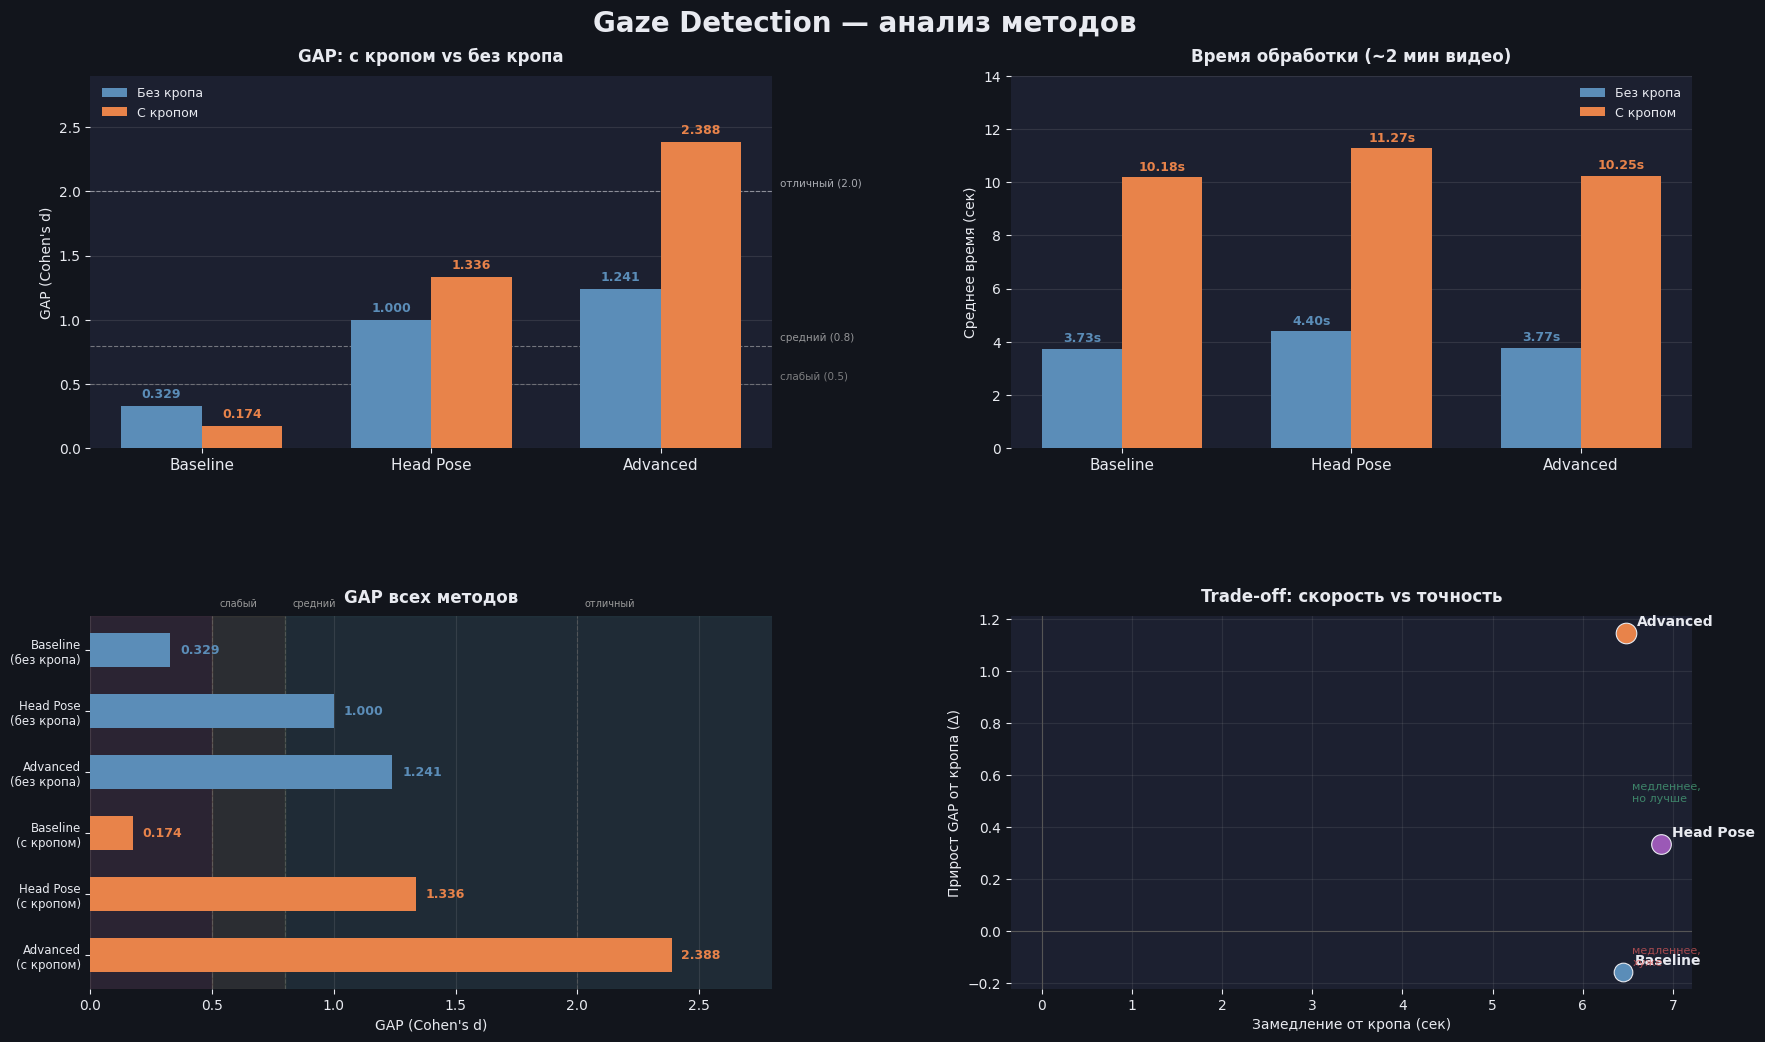

Инфографика сохранена: ../media/gaze_analysis_infographic.png


In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

methods       = ['Baseline', 'Head Pose', 'Advanced']
gap_no_crop   = [0.329, 1.000, 1.241]
gap_with_crop = [0.174, 1.336, 2.388]
time_no_crop  = [3.73,  4.40,  3.77]
time_with_crop= [10.18, 11.27, 10.25]

# Цветовая палитра
C_NC   = '#5B8DB8'   # синий  — без кропа
C_WC   = '#E8834A'   # оранжевый — с кропом
C_GOOD = '#4CAF82'   # зелёный — хорошо
C_BAD  = '#E05C5C'   # красный — плохо
BG     = '#12151C'
PANEL  = '#1C2030'
TEXT   = '#E8EAF0'

x = np.arange(len(methods))
w = 0.35

fig = plt.figure(figsize=(18, 11), facecolor=BG)
fig.suptitle('Gaze Detection — анализ методов', fontsize=20,
             color=TEXT, fontweight='bold', y=0.97)

gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35,
                      left=0.07, right=0.96, top=0.91, bottom=0.08)

# ------------------------------------------------------------------
# 1. GAP: сравнение с кропом и без (grouped bar)
# ------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(PANEL)

bars_nc = ax1.bar(x - w/2, gap_no_crop,   w, color=C_NC, label='Без кропа',
                  edgecolor='none', zorder=3)
bars_wc = ax1.bar(x + w/2, gap_with_crop, w, color=C_WC, label='С кропом',
                  edgecolor='none', zorder=3)

# Подписи значений
for bar in bars_nc:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
             f'{bar.get_height():.3f}', ha='center', va='bottom',
             fontsize=9, color=C_NC, fontweight='bold')
for bar in bars_wc:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
             f'{bar.get_height():.3f}', ha='center', va='bottom',
             fontsize=9, color=C_WC, fontweight='bold')

# Пороги Cohen's d
for y_val, label, color in [(0.5, 'слабый (0.5)', '#aaa'), (0.8, 'средний (0.8)', '#ccc'),
                              (2.0, 'отличный (2.0)', TEXT)]:
    ax1.axhline(y_val, ls='--', lw=0.8, color=color, alpha=0.5, zorder=2)
    ax1.text(2.52, y_val + 0.04, label, fontsize=7.5, color=color, alpha=0.7)

ax1.set_xticks(x); ax1.set_xticklabels(methods, color=TEXT, fontsize=11)
ax1.set_ylabel("GAP (Cohen's d)", color=TEXT, fontsize=10)
ax1.set_title("GAP: с кропом vs без кропа", color=TEXT, fontsize=12, fontweight='bold', pad=10)
ax1.set_ylim(0, 2.9)
ax1.tick_params(colors=TEXT); ax1.spines[:].set_visible(False)
ax1.yaxis.label.set_color(TEXT); ax1.grid(axis='y', alpha=0.15, zorder=1)
ax1.legend(facecolor=PANEL, edgecolor='none', labelcolor=TEXT, fontsize=9)

# ------------------------------------------------------------------
# 2. Время: сравнение с кропом и без
# ------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(PANEL)

bars_t_nc = ax2.bar(x - w/2, time_no_crop,   w, color=C_NC, label='Без кропа',
                    edgecolor='none', zorder=3)
bars_t_wc = ax2.bar(x + w/2, time_with_crop, w, color=C_WC, label='С кропом',
                    edgecolor='none', zorder=3)

for bar in bars_t_nc:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             f'{bar.get_height():.2f}s', ha='center', va='bottom',
             fontsize=9, color=C_NC, fontweight='bold')
for bar in bars_t_wc:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             f'{bar.get_height():.2f}s', ha='center', va='bottom',
             fontsize=9, color=C_WC, fontweight='bold')

ax2.set_xticks(x); ax2.set_xticklabels(methods, color=TEXT, fontsize=11)
ax2.set_ylabel('Среднее время (сек)', color=TEXT, fontsize=10)
ax2.set_title('Время обработки (~2 мин видео)', color=TEXT, fontsize=12, fontweight='bold', pad=10)
ax2.set_ylim(0, 14)
ax2.tick_params(colors=TEXT); ax2.spines[:].set_visible(False)
ax2.yaxis.label.set_color(TEXT); ax2.grid(axis='y', alpha=0.15, zorder=1)
ax2.legend(facecolor=PANEL, edgecolor='none', labelcolor=TEXT, fontsize=9)

# ------------------------------------------------------------------
# 3. GAP всех методов — горизонтальный bullet-chart
# ------------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(PANEL)

labels_all = [f'{m}\n(без кропа)' for m in methods] + [f'{m}\n(с кропом)' for m in methods]
vals_all   = gap_no_crop + gap_with_crop
colors_all = [C_NC]*3 + [C_WC]*3
y_pos      = list(range(len(labels_all)))

bars_h = ax3.barh(y_pos, vals_all, color=colors_all, edgecolor='none',
                  height=0.55, zorder=3)

for i, (bar, val) in enumerate(zip(bars_h, vals_all)):
    ax3.text(val + 0.04, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9,
             color=colors_all[i], fontweight='bold')

# Фоновые зоны
ax3.axvspan(0,   0.5, alpha=0.08, color=C_BAD,  zorder=1)
ax3.axvspan(0.5, 0.8, alpha=0.08, color='#E8C94A', zorder=1)
ax3.axvspan(0.8, 3.0, alpha=0.08, color=C_GOOD,  zorder=1)

for xv, lbl in [(0.5, 'слабый'), (0.8, 'средний'), (2.0, 'отличный')]:
    ax3.axvline(xv, ls='--', lw=0.8, color='#666', alpha=0.6)
    ax3.text(xv + 0.03, -0.7, lbl, fontsize=7, color='#999')

ax3.set_yticks(y_pos); ax3.set_yticklabels(labels_all, color=TEXT, fontsize=8.5)
ax3.set_xlabel("GAP (Cohen's d)", color=TEXT, fontsize=10)
ax3.set_title('GAP всех методов', color=TEXT, fontsize=12, fontweight='bold', pad=10)
ax3.set_xlim(0, 2.8)
ax3.tick_params(colors=TEXT); ax3.spines[:].set_visible(False)
ax3.xaxis.label.set_color(TEXT); ax3.grid(axis='x', alpha=0.15, zorder=1)
ax3.invert_yaxis()

# ------------------------------------------------------------------
# 4. Trade-off: Δ GAP vs Δ Time (scatter)
# ------------------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(PANEL)

delta_gap  = [g_wc - g_nc for g_wc, g_nc in zip(gap_with_crop, gap_no_crop)]
delta_time = [t_wc - t_nc for t_wc, t_nc in zip(time_with_crop, time_no_crop)]
colors_sc  = [C_NC, '#9B59B6', C_WC]
sizes      = [180, 200, 220]

for i, (m, dg, dt) in enumerate(zip(methods, delta_gap, delta_time)):
    ax4.scatter(dt, dg, s=sizes[i], color=colors_sc[i], zorder=5,
                edgecolors=TEXT, linewidths=0.8)
    ax4.annotate(m, (dt, dg),
                 textcoords='offset points', xytext=(8, 5),
                 fontsize=10, color=TEXT, fontweight='bold')

# Квадранты
ax4.axhline(0, color='#555', lw=0.8)
ax4.axvline(0, color='#555', lw=0.8)
ax4.text(6.55, -0.13, 'медленнее,\nхуже', fontsize=8, color='#E05C5C', alpha=0.7)
ax4.text(6.55,  0.5,  'медленнее,\nно лучше', fontsize=8, color=C_GOOD, alpha=0.7)

ax4.set_xlabel('Замедление от кропа (сек)', color=TEXT, fontsize=10)
ax4.set_ylabel('Прирост GAP от кропа (Δ)', color=TEXT, fontsize=10)
ax4.set_title('Trade-off: скорость vs точность', color=TEXT, fontsize=12,
              fontweight='bold', pad=10)
ax4.tick_params(colors=TEXT); ax4.spines[:].set_visible(False)
ax4.xaxis.label.set_color(TEXT); ax4.yaxis.label.set_color(TEXT)
ax4.grid(alpha=0.12, zorder=1)

plt.savefig('../media/gaze_analysis_infographic.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("Инфографика сохранена: ../media/gaze_analysis_infographic.png")
